# Airline Customer Loyalty & Retention Analysis

## Project Goal

When I started this project, I wanted to understand what separates customers who remain active in the loyalty program from those who decide to leave.

My initial assumption was that customer characteristics such as CLV, salary, or loyalty card type would explain most of the differences between active and cancelled customers.

The goal of this analysis is to identify the factors that appear to be most closely associated with customer retention.

# Understanding the Data

The analysis combines two datasets.

The first contains customer information such as demographics, loyalty program details, and cancellation history.

The second contains flight activity information, including flights, distance traveled, and loyalty points earned and redeemed.

By combining both datasets, I can compare not only who the customers are, but also how they interact with the loyalty program.

In [4]:
import pandas as pd

loyalty = pd.read_csv("Customer Loyalty History.csv")
activity = pd.read_csv("Customer Flight Activity.csv")

print("LOYALTY")
print(loyalty.shape)

print("\nACTIVITY")
print(activity.shape)

print("\nLOYALTY COLUMNS")
print(loyalty.columns.tolist())

print("\nACTIVITY COLUMNS")
print(activity.columns.tolist())

LOYALTY
(16737, 16)

ACTIVITY
(392936, 8)

LOYALTY COLUMNS
['Loyalty Number', 'Country', 'Province', 'City', 'Postal Code', 'Gender', 'Education', 'Salary', 'Marital Status', 'Loyalty Card', 'CLV', 'Enrollment Type', 'Enrollment Year', 'Enrollment Month', 'Cancellation Year', 'Cancellation Month']

ACTIVITY COLUMNS
['Loyalty Number', 'Year', 'Month', 'Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed', 'Dollar Cost Points Redeemed']


In [7]:
loyalty.head()

,Loyalty Number,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Cancelled
0,480934,Canada,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,NaN,NaN,0
1,549612,Canada,Alberta,Edmonton,T3G 6Y6,Male,College,NaN,Divorced,Star,3839.61,Standard,2016,3,NaN,NaN,0
2,429460,Canada,British Columbia,Vancouver,V6E 3D9,Male,College,NaN,Single,Star,3839.75,Standard,2014,7,2018.0,1.0,1
3,608370,Canada,Ontario,Toronto,P1W 1K4,Male,College,NaN,Single,Star,3839.75,Standard,2013,2,NaN,NaN,0
4,530508,Canada,Quebec,Hull,J8Y 3Z5,Male,Bachelor,103495.0,Married,Star,3842.79,Standard,2014,10,NaN,NaN,0


In [8]:
activity.head()

,Loyalty Number,Year,Month,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100590,2018,6,12,15276,22914.0,0,0
1,100590,2018,7,12,9168,13752.0,0,0
2,100590,2018,5,4,6504,9756.0,0,0
3,100590,2018,10,0,0,0.0,512,92
4,100590,2018,2,0,0,0.0,0,0


# First Questions

Before looking at customer activity, I wanted to start with a few basic questions:

- Do cancelled customers have a lower CLV?
- Are certain loyalty card tiers more likely to cancel?
- Does enrollment type make a difference?

These seemed like reasonable starting points before exploring customer behavior.

## Identifying Cancelled Customers

Before doing any analysis, I needed a way to separate active customers from customers who had cancelled their membership.

I created a new variable called `Cancelled`, where active customers are labeled as 0 and cancelled customers as 1.

In [5]:
loyalty['Cancelled'] = loyalty['Cancellation Year'].notna().astype(int)

loyalty['Cancelled'].value_counts()

,count
Cancelled,
0,14670
1,2067


In [9]:
loyalty['Cancelled'].value_counts(normalize=True) * 100

,proportion
Cancelled,
0,87.650117
1,12.349883


### Notes

Around 12% of customers in the dataset cancelled their membership.

This should give me enough cancelled customers to compare against the active group and look for potential patterns.

## Looking at CLV

One of my first questions was whether customers who cancelled the program had a lower Customer Lifetime Value (CLV).

My assumption was that lower-value customers might be more likely to leave.

In [10]:
loyalty.groupby('Cancelled')['CLV'].mean()

,CLV
Cancelled,
0,7968.764740
1,8131.776768


### Notes

I expected customers with lower CLV to be more likely to cancel, but that doesn't seem to be the case.

The difference was much smaller than I expected and doesn't appear particularly meaningful.

## Loyalty Card

After looking at CLV, I wanted to check whether loyalty card type had any relationship with cancellations.

I was curious to see if customers with higher-tier cards were more likely to remain in the program.

In [11]:
loyalty.groupby('Cancelled')['Loyalty Card'].value_counts(normalize=True) * 100

Cancelled  Loyalty Card
0          Star            45.916837
           Nova            33.769598
           Aurora          20.313565
1          Star            43.589744
           Nova            34.687954
           Aurora          21.722303
Name: proportion, dtype: float64

### Notes

I was expecting to see larger differences across loyalty card tiers, but the distributions were almost identical.

At least from this comparison, card type doesn't seem to explain why customers leave the program.

## Enrollment Type

Next, I looked at how customers joined the loyalty program.

I wanted to see whether customers who enrolled through a promotion behaved differently from those who joined through the standard enrollment process.

In [12]:
loyalty.groupby('Cancelled')['Enrollment Type'].value_counts(normalize=True) * 100

Cancelled  Enrollment Type
0          Standard           94.164963
           2018 Promotion      5.835037
1          Standard           94.436381
           2018 Promotion      5.563619
Name: proportion, dtype: float64

### Notes

Nothing particularly interesting showed up here.

Customers who joined through promotions and those who joined through the standard process behaved very similarly.

In [13]:
import pandas as pd

loyalty = pd.read_csv("Customer Loyalty History.csv")
activity = pd.read_csv("Customer Flight Activity.csv")

In [14]:
print(loyalty.shape)
print(activity.shape)

(16737, 16)
(392936, 8)


## Combining the Data

So far, I had only been working with customer information.

To get a better picture of customer behavior, I combined the loyalty dataset with the flight activity dataset.

In [15]:
activity_summary = activity.groupby('Loyalty Number').agg({
    'Total Flights': 'sum',
    'Distance': 'sum',
    'Points Accumulated': 'sum',
    'Points Redeemed': 'sum',
    'Dollar Cost Points Redeemed': 'sum'
}).reset_index()

In [16]:
customer_data = loyalty.merge(
    activity_summary,
    on='Loyalty Number',
    how='left'
)

customer_data.shape

(16737, 21)

### Notes

Now that both datasets are combined, I can start looking at customer behavior instead of only customer characteristics.

This should give a much clearer picture of what separates active and cancelled customers.

## Flight Activity

At this point, none of the customer profile variables seemed particularly useful.

I wanted to see whether actual customer behavior could explain the differences between active and cancelled members.

In [17]:
customer_data['Cancelled'] = customer_data['Cancellation Year'].notna().astype(int)

customer_data.groupby('Cancelled')[
    ['Total Flights', 'Distance', 'Points Accumulated', 'Points Redeemed']
].mean()

,Total Flights,Distance,Points Accumulated,Points Redeemed
Cancelled,,,,
0,33.256714,49846.465781,51903.841547,807.833742
1,10.126754,15294.675375,16990.632317,217.537978


### Notes

This is the first result that really stands out.

Cancelled customers flew much less, traveled shorter distances, and accumulated far fewer points than active customers.

The differences are much larger than anything I found in the profile-related variables.

### Early Observation

One of the clearest patterns in the analysis so far is the difference in activity levels between active and cancelled customers.

Customers who cancelled the loyalty program tended to fly much less, travel shorter distances, and accumulate far fewer points than customers who remained active.

At this stage, customer activity appears to be more closely associated with cancellations than variables such as loyalty card tier, enrollment type, or customer lifetime value.

## Looking at Loyalty Points

After finding clear differences in flight activity, I became curious about how customers were using the loyalty program itself.

I decided to compare points accumulation and redemption between active and cancelled customers..

In [18]:
customer_data.groupby('Cancelled')[
    ['Points Accumulated', 'Points Redeemed']
].median()

,Points Accumulated,Points Redeemed
Cancelled,,
0,52743.5,661.0
1,4740.0,0.0


### Notes

Active customers accumulated far more points than cancelled customers.

I also noticed that the typical cancelled customer redeemed no points at all, which made me wonder whether engagement with the program is more important than customer profile information.

In [19]:
customer_data.groupby('Cancelled')['Enrollment Year'].median()

,Enrollment Year
Cancelled,
0,2015.0
1,2015.0


In [20]:
customer_data[['Enrollment Year',
               'Cancellation Year']].sample(10)

,Enrollment Year,Cancellation Year
48,2015,NaN
12451,2015,NaN
10558,2018,NaN
7001,2018,NaN
12793,2017,NaN
1669,2017,NaN
8042,2015,NaN
3678,2012,NaN
15496,2013,NaN
4853,2014,NaN


## How Long Do Customers Stay?

I wanted to understand how long customers typically remained in the program before cancelling their membership.

To do that, I calculated the time between enrollment and cancellation for customers who had left the program.

In [21]:
cancelled_customers = customer_data[customer_data['Cancelled'] == 1].copy()

cancelled_customers['Membership Duration'] = (
    cancelled_customers['Cancellation Year'] -
    cancelled_customers['Enrollment Year']
)

cancelled_customers['Membership Duration'].describe()

,Membership Duration
count,2067.000000
mean,1.268021
std,1.265660
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


### Notes

Most cancellations seem to happen relatively early.

The typical customer who leaves the program does so after about one year of membership.

## Activity and Membership Duration

After calculating membership duration, I wanted to see whether customers who stayed longer in the program were also more active.

I used flight activity to explore that relationship.

In [22]:
cancelled_customers.groupby('Membership Duration')[
    'Total Flights'
].median().sort_index()

,Total Flights
Membership Duration,
0.0,0.0
1.0,0.0
2.0,1.0
3.0,10.0
4.0,20.0
5.0,29.0


### Notes

Customers who stayed in the program longer were also much more active.

The pattern isn't perfect, but activity appears to increase with membership duration.

### Early Cancellations and Customer Activity

One of the most interesting patterns in the data is how quickly many customers leave the loyalty program.

Customers who cancelled within their first one or two years of membership showed almost no flight activity. In contrast, customers who stayed in the program for several years were much more active and tended to take significantly more flights.

This suggests that activity levels may be closely linked to retention. Customers who rarely use the program after joining seem far more likely to leave, while customers who continue flying remain engaged for longer.


## Customers with No Flight Activity

While looking at flight activity, I started wondering how many customers had never actually used the program.

I compared active and cancelled customers to see whether a lack of activity was related to cancellations.

In [23]:
customer_data.groupby('Cancelled')['Total Flights'].apply(
    lambda x: (x == 0).mean() * 100
)

,Total Flights
Cancelled,
0,4.219496
1,46.008708


### Notes

I wasn't expecting the difference to be this large.

Nearly half of the cancelled customers never took a flight, while only a small percentage of active customers showed no activity.

This feels like one of the strongest signals in the analysis so far.

## Checking the Points Data

Before continuing, I wanted to confirm whether flight activity and points accumulation were telling the same story.

This helped me avoid analyzing two variables that might be measuring exactly the same behavior.

In [24]:
customer_data.groupby('Cancelled')['Points Accumulated'].apply(
    lambda x: (x == 0).mean() * 100
)

,Points Accumulated
Cancelled,
0,4.219496
1,46.008708


In [25]:
(
    (customer_data['Total Flights'] == 0) ==
    (customer_data['Points Accumulated'] == 0)
).mean()

np.float64(1.0)

### Notes

After checking the data, I found that customers with zero flights also accumulated zero points.

Since both variables tell the same story, I'll focus on flight activity moving forward.

## Looking at Salary

Most of the differences so far seemed to come from customer behavior rather than customer characteristics.

I wanted to check whether income levels showed any meaningful differences between active and cancelled customers.

In [26]:
customer_data.groupby('Cancelled')['Salary'].median()

,Salary
Cancelled,
0,73492.0
1,73143.0


### Notes

I was curious to see whether income levels played a role, but the difference was almost nonexistent.

Once again, customer behavior seems much more informative than customer characteristics.

## Flight Activity and Cancellations

Customers who cancelled the program seemed to fly much less.

To explore this further, I will compare cancellation rates across different flight activity groups.

In [27]:
customer_data['Total Flights'].describe()

,Total Flights
count,16737.000000
mean,30.400191
std,16.865558
min,0.000000
25%,20.000000
50%,34.000000
75%,42.000000
max,106.000000


## Flight Activity Segments

The previous results showed that customers with fewer flights were much more likely to cancel.

To explore this further, I grouped customers based on their flight activity and compared cancellation rates across different activity levels.

In [28]:
customer_data['Flight Segment'] = pd.qcut(
    customer_data['Total Flights'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

customer_data.groupby('Flight Segment')['Cancelled'].mean() * 100

/tmp/ipykernel_16660/1310574012.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('Flight Segment')['Cancelled'].mean() * 100


,Cancelled
Flight Segment,
Low,39.427774
Medium-Low,5.015466
Medium-High,1.608187
High,2.074580


### Flight Activity and Cancellations

The biggest difference appears among customers with the lowest flight activity.

Almost 40% of customers in the low activity group cancelled their membership, compared with less than 6% in the other segments.

This suggests that the relationship between activity and retention is not gradual. Instead, the highest risk of cancellation appears among customers who rarely engage with the program.

## Looking at Flight Distribution

Flight activity appears to be strongly related to cancellations.

Before moving on, I want to get a better understanding of how flights are distributed across customers and whether there are natural thresholds that separate low and highly engaged members.

In [29]:
customer_data['Total Flights'].describe(
    percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
)

,Total Flights
count,16737.000000
mean,30.400191
std,16.865558
min,0.000000
10%,2.000000
20%,14.000000
30%,24.000000
40%,30.000000
50%,34.000000
60%,37.000000


### Notes

The difference between activity groups was much larger than I expected.

Customers in the lowest activity segment had a cancellation rate close to 40%, while cancellation rates remained very low across all other groups.

This makes me think that the biggest risk factor isn't simply flying less. The real difference seems to appear among customers with very little activity.

## Focusing on Low Activity Customers

The previous results suggest that the highest cancellation risk is concentrated among customers with very low flight activity.

I want to take a closer look at this group and see if there is a specific flight range where cancellation rates start to increase.

In [30]:
customer_data['Flight Band'] = pd.cut(
    customer_data['Total Flights'],
    bins=[-1, 0, 10, 20, 30, 40, 120],
    labels=[
        '0',
        '1-10',
        '11-20',
        '21-30',
        '31-40',
        '40+'
    ]
)

customer_data.groupby('Flight Band')['Cancelled'].mean() * 100

/tmp/ipykernel_16660/1386521508.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('Flight Band')['Cancelled'].mean() * 100


,Cancelled
Flight Band,
0,60.573248
1-10,25.527273
11-20,29.025111
21-30,6.420973
31-40,2.133174
40+,2.004175


### Notes

Breaking flight activity into smaller groups revealed a much clearer pattern.

Customers with fewer than 20 flights showed cancellation rates between 25% and 60%, while customers with more than 20 flights had much lower cancellation rates.

The sharp drop after the 20-flight mark suggests that retention improves significantly once customers become more active in the program.

## Looking at Point Redemption

Flight activity has been one of the strongest indicators so far.

Next, I want to see whether customers who actually use their loyalty points show different cancellation patterns than customers who never redeem rewards.

In [31]:
customer_data['Redeemed Points'] = (
    customer_data['Points Redeemed'] > 0
).astype(int)

customer_data.groupby('Redeemed Points')['Cancelled'].mean() * 100

,Cancelled
Redeemed Points,
0,28.533333
1,4.953426


### Notes

This turned out to be one of the strongest differences in the analysis.

Customers who never redeemed points had a cancellation rate close to 29%, while customers who redeemed rewards cancelled much less frequently.

At this point, it looks like using the loyalty program may be just as important as flying. Customers who actively redeem rewards appear much more likely to remain members.

## Flights vs Point Redemption

Both flight activity and point redemption seem to be closely related to cancellations.

Before drawing any conclusions, I want to check whether these two behaviors are strongly connected to each other.

In [32]:
customer_data.groupby('Redeemed Points')[
    'Total Flights'
].median()

,Total Flights
Redeemed Points,
0,12.0
1,37.0


### Notes

Customers who redeemed points were also much more active overall.

The typical customer who never redeemed rewards had only 12 flights, compared with 37 flights for customers who used their points.

This suggests that point redemption and flight activity are closely connected. Customers who actively participate in the loyalty program also tend to be more active travelers.

## Looking at Customer Profile Variables

Most of the strongest patterns so far have been related to customer behavior.

Before moving on, I want to check whether basic customer characteristics show any meaningful differences in cancellation rates.

In [33]:
customer_data.groupby('Education')['Cancelled'].mean() * 100

,Cancelled
Education,
Bachelor,12.276850
College,12.435111
Doctor,13.079019
High School or Below,11.892583
Master,12.795276


### Notes

I expected to see at least some variation across education levels, but the differences were very small.

Cancellation rates remained fairly consistent across all groups, which suggests that education is probably not a major factor in explaining why customers leave the program.

## Looking at Marital Status

Education did not show any meaningful differences.

Next, I want to check whether cancellation rates vary across different marital status groups.

In [34]:
customer_data.groupby('Marital Status')['Cancelled'].mean() * 100

,Cancelled
Marital Status,
Divorced,11.556791
Married,12.470467
Single,12.533452


### Notes

Just like education, marital status doesn't seem to make much of a difference.

Cancellation rates were very similar across all groups, which reinforces the idea that customer behavior may be more important than customer characteristics when explaining cancellations.

## Looking at Gender

So far, most profile-related variables have shown very little relationship with cancellations.

I want to check one last customer characteristic before focusing entirely on engagement and activity patterns.

In [35]:
customer_data.groupby('Gender')['Cancelled'].mean() * 100

,Cancelled
Gender,
Female,12.544590
Male,12.153236


### Notes

The difference between male and female customers was very small.

At this point, none of the customer profile variables I've explored seem to explain cancellations particularly well.

The strongest patterns continue to come from customer behavior rather than customer characteristics.

## Building an Engagement Score

Most of the strongest signals so far have been related to customer activity and participation in the loyalty program.

Instead of looking at each variable separately, I want to combine a few engagement indicators and see whether highly engaged customers are less likely to cancel.

In [36]:
customer_data['Engaged Customer'] = (
    (customer_data['Total Flights'] > 20) &
    (customer_data['Points Redeemed'] > 0)
).astype(int)

customer_data.groupby('Engaged Customer')['Cancelled'].mean() * 100

,Cancelled
Engaged Customer,
0,28.317203
1,2.448940


### Notes

Combining flight activity and point redemption made the pattern even clearer.

Customers who were actively using the program had a cancellation rate of just 2.4%, compared with more than 28% among less engaged customers.

This was one of the strongest differences I found in the analysis and reinforces the idea that engagement is closely linked to retention.

## Building a Simple Churn Model

So far, several variables seem to be related to cancellations, especially flight activity and engagement with the loyalty program.

I want to take the analysis one step further and build a simple model to see which factors are most useful when explaining customer cancellations.

In [37]:
features = customer_data[[
    'Total Flights',
    'Distance',
    'Points Redeemed',
    'Salary',
    'CLV'
]].copy()

target = customer_data['Cancelled']

features = features.fillna(0)

### Preparing the Data

To keep things simple, I selected a mix of customer profile variables and behavioral variables.

This should help me compare which type of information contributes the most when explaining cancellations.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.3,
    random_state=42
)

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

### Training the Model

I used a simple Logistic Regression model as a starting point.

The goal is not to build the best predictive model, but to understand which variables appear to have the strongest relationship with customer cancellations.

In [39]:
import pandas as pd

coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_[0]
})

coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
0,Total Flights,-7.832789e-02
2,Points Redeemed,-5.341127e-04
1,Distance,-4.441987e-06
4,CLV,7.473938e-07
3,Salary,-5.545777e-07


### Notes

The first model points in the same

## Standardizing the Variables

The first model suggested that flight activity may be the strongest factor associated with cancellations.

However, the variables are measured on very different scales, so I want to standardize them before comparing their coefficients.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(features)

model_scaled = LogisticRegression(max_iter=5000)

model_scaled.fit(X_scaled, target)

scaled_coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model_scaled.coef_[0]
})

scaled_coefficients.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
0,Total Flights,-1.522508
2,Points Redeemed,-0.389775
1,Distance,0.104057
3,Salary,-0.020713
4,CLV,0.001149


### Notes

After standardizing the variables, flight activity remained the strongest factor in the model.

Total Flights had the largest coefficient by far, which supports what appeared earlier in the analysis: customers who fly more are much less likely to cancel.

Points Redeemed also showed a relationship with cancellations, but it was weaker than flight activity. Customer profile variables such as Salary and CLV had very little influence in this simple model.

## Evaluating the Model

After training the model, I wanted to check how well it could distinguish between active and cancelled customers.

The goal here is not to build a production-ready model, but to see whether the variables included in the analysis contain enough information to identify customers at higher risk of cancellation.

In [41]:
from sklearn.metrics import accuracy_score

predictions = model_scaled.predict(X_scaled)

accuracy_score(target, predictions)

0.8944852721515206

### Notes

The model achieved an accuracy of almost 90%.

At first glance, this looks very promising. However, cancellations represent a relatively small portion of the dataset, so accuracy alone may not tell the full story.

I want to take a closer look at how well the model identifies cancelled customers before drawing any conclusions.

## Looking Beyond Accuracy

Most customers in the dataset remain active, which means a high accuracy score can sometimes be misleading.

To better evaluate the model, I want to see how well it performs for both active and cancelled customers separately.

In [42]:
from sklearn.metrics import classification_report

print(classification_report(target, predictions))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94     14670
           1       0.59      0.46      0.52      2067

    accuracy                           0.89     16737
   macro avg       0.76      0.71      0.73     16737
weighted avg       0.89      0.89      0.89     16737



### Notes

The model did a good job identifying active customers, but it missed quite a few cancelled customers.

This wasn't too surprising given that cancellations only represent a small part of the dataset.

Even though the model is far from perfect, it still reinforces something I've seen throughout the analysis: customer activity seems to be much more useful than customer profile information when trying to explain cancellations.

## Testing the Engagement Variable

Earlier in the analysis, I created a simple engagement indicator based on flight activity and point redemption.

Since this variable showed a strong relationship with cancellations, I want to see how well it performs on its own.

In [43]:
customer_data.groupby('Engaged Customer')['Cancelled'].agg(
    ['count', 'mean']
)

,count,mean
Engaged Customer,,
0,6406,0.283172
1,10331,0.024489


### Notes

This custom engagement variable turned out to be very useful.

Less engaged customers made up 6,406 customers and had a cancellation rate of about 28%.

Engaged customers made up a larger group, 10,331 customers, but their cancellation rate was only about 2.4%.

This is one of the clearest results in the analysis: customers who both fly regularly and redeem points are much less likely to cancel their membership.

## Looking at Geography

Most of the strongest patterns so far have been related to customer engagement.

Before wrapping up the analysis, I want to explore whether cancellation rates vary across different provinces.

In [44]:
province_churn = (
    customer_data.groupby('Province')['Cancelled']
    .mean()
    .sort_values(ascending=False)
    * 100
)

province_churn

,Cancelled
Province,
Prince Edward Island,16.666667
Manitoba,15.197568
Newfoundland,14.728682
Alberta,12.590299
Quebec,12.515152
Ontario,12.472243
Saskatchewan,12.224939
British Columbia,11.839419
Nova Scotia,11.196911


### Notes

There are some differences across provinces, but they are much smaller than the differences I found in customer activity and engagement.

A few provinces show slightly higher cancellation rates, but overall the variation is fairly limited.

At this stage, geography does not appear to be as useful as flight activity or reward usage when explaining cancellations.

## Looking at Travel Patterns

Most of the analysis has focused on how often customers fly.

Before finishing, I want to explore whether travel patterns differ between active and cancelled customers by looking at the average distance travelled per flight.

In [45]:
customer_data['Distance per Flight'] = (
    customer_data['Distance'] /
    customer_data['Total Flights']
)

customer_data['Distance per Flight'] = (
    customer_data['Distance per Flight']
    .replace([float('inf'), -float('inf')], 0)
    .fillna(0)
)

customer_data.groupby('Cancelled')[
    'Distance per Flight'
].median()

,Distance per Flight
Cancelled,
0,1488.273101
1,1030.000000


### Notes

I wasn't expecting a large difference here, but active customers tended to travel longer distances per flight.

The gap is noticeable, although it is much smaller than the differences seen in flight activity and engagement.

This suggests that how often customers use the program matters more than the type of trips they take.

## Visualizing Flight Activity

Flight activity was one of the first variables that showed a clear relationship with cancellations.

To make the pattern easier to see, I grouped customers by activity level and compared cancellation rates across the different segments.

/tmp/ipykernel_16660/971898376.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('Flight Segment')['Cancelled']


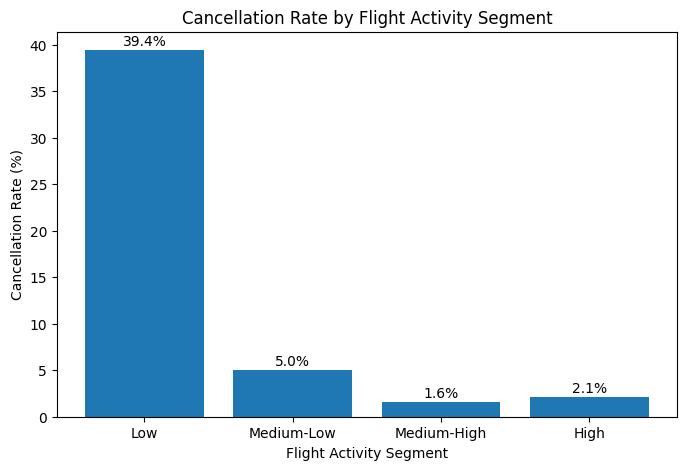

In [48]:
import matplotlib.pyplot as plt

flight_churn = (
    customer_data.groupby('Flight Segment')['Cancelled']
    .mean()
    .reset_index()
)

flight_churn['Cancelled'] *= 100

plt.figure(figsize=(8,5))

plt.bar(
    flight_churn['Flight Segment'],
    flight_churn['Cancelled']
)

plt.title('Cancellation Rate by Flight Activity Segment')
plt.xlabel('Flight Activity Segment')
plt.ylabel('Cancellation Rate (%)')

for i, value in enumerate(flight_churn['Cancelled']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

plt.show()

### Notes

This was the point where the story started to become much clearer.

Customers in the low activity group were much more likely to cancel than everyone else.

What surprised me was how quickly the cancellation rate dropped once customers became more active. After that first group, the differences between segments became much smaller.

## Visualizing Engagement

After looking at several activity metrics, I created a simple engagement variable based on flight activity and reward redemption.

This ended up being one of the strongest findings in the project.

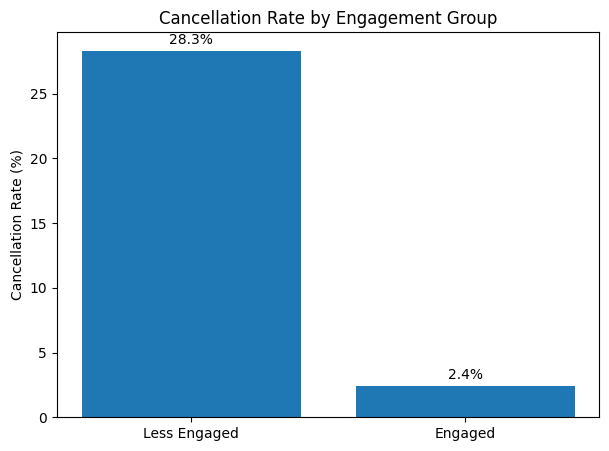

In [49]:
import matplotlib.pyplot as plt

engagement_churn['Group'] = (
    engagement_churn['Engaged Customer']
    .map({
        0: 'Less Engaged',
        1: 'Engaged'
    })
)

plt.figure(figsize=(7,5))

plt.bar(
    engagement_churn['Group'],
    engagement_churn['Cancelled']
)

plt.title('Cancellation Rate by Engagement Group')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('')

for i, value in enumerate(engagement_churn['Cancelled']):
    plt.text(i, value + 0.5, f'{value:.1f}%', ha='center')

plt.show()

### Notes

This ended up being the clearest result in the entire analysis.

The difference between both groups was much larger than I expected when I first created the engagement variable.

Customers who actively used the program were far less likely to cancel, which reinforces the idea that engagement plays a much bigger role than customer profile characteristics.

## What the Model Found

After exploring the data manually, I trained a simple logistic regression model to see which variables were most useful when explaining cancellations.

The results were consistent with the patterns observed throughout the analysis.

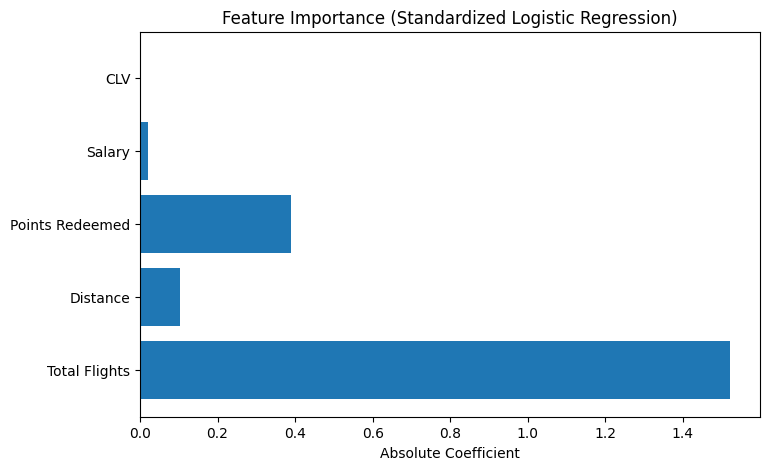

In [50]:
feature_importance = scaled_coefficients.copy()

plt.figure(figsize=(8,5))

plt.barh(
    feature_importance['Feature'],
    abs(feature_importance['Coefficient'])
)

plt.title('Feature Importance (Standardized Logistic Regression)')
plt.xlabel('Absolute Coefficient')

plt.show()

### Notes

I wasn't sure if the model would tell the same story as the exploratory analysis, but the results were surprisingly consistent.

Flight activity was by far the most important variable, with a much larger impact than any other feature in the model.

Point redemption also contributed, although its effect was noticeably smaller.

What stood out to me was how little influence variables like salary and CLV had. Earlier in the project I expected customer profile information to play a bigger role, but the model reinforced the idea that customer behavior is much more useful when trying to explain cancellations.

# Key Findings

### Customer profile variables were not very useful

At the beginning of the project, I expected variables like CLV, salary, loyalty card type, or education level to explain why some customers left the program.

After exploring them one by one, I found very little difference between active and cancelled customers.

---

### Flight activity was one of the strongest signals

The biggest differences started to appear when I looked at customer activity.

Customers who cancelled the program generally flew much less than active customers, and cancellation rates increased sharply among low-activity customers.

---

### Customers who never really use the program are much more likely to leave

One result that immediately caught my attention was the number of cancelled customers who never took a flight.

Nearly half of the customers who cancelled had no flight activity at all, which was much higher than I expected.

---

### Reward redemption seems to matter

Customers who redeemed points were much less likely to cancel than customers who never used their rewards.

This made me think that simply joining the program is not enough. Actually using its benefits appears to be much more important.

---

### Engagement was the clearest pattern in the data

The strongest result came from the engagement variable I created using flight activity and reward redemption.

Customers who actively used the program had a very low cancellation rate, while less engaged customers were much more likely to leave.

# What I Would Do Next

After spending time exploring the data, a few ideas stood out to me.

The strongest patterns were consistently related to customer activity and engagement, so that is where I would focus most of my attention.

### Encourage Early Activity

One of the most surprising findings was how many cancelled customers never took a flight.

Because of that, I would be interested in understanding what happens during a customer's first months in the program and how to encourage earlier participation.

### Make Rewards Easier to Use

Customers who redeemed points were much less likely to cancel.

This makes me think that helping customers use their rewards sooner could increase the perceived value of the program.

### Monitor Low-Activity Customers

Customers with very low flight activity repeatedly showed the highest cancellation rates.

If I were working with this program, I would probably pay special attention to customers who show little activity after joining.

# Things I Could Not Explore

There are still a few questions that this dataset cannot answer.

For example, I don't know why customers decided to leave the program. I can see patterns in their behavior, but I can't see customer feedback, service interactions, booking issues, or other factors that may have influenced their decision.

If I had access to additional data, I would be interested in exploring those areas next.

# Final Thoughts

When I started this project, I expected customer profile information to explain most of the differences between active and cancelled customers.

Instead, the analysis kept pointing me toward customer behavior.

The more I explored the data, the clearer it became that activity and engagement were much more useful than variables such as salary, education, loyalty card type, or enrollment method.

The result that stayed with me the most was how many cancelled customers never took a flight. That finding completely changed the direction of the analysis and led me to focus on engagement for the rest of the project.

If I continued this work, I would spend more time understanding what helps new members become active customers and what causes some of them to disengage so early.